# Optimisation CPU des Transformers sur LIAR

Ce notebook vise à maximiser le F1 pondéré de DistilBERT et RoBERTa sur le dataset LIAR, en environnement **CPU-only**.

Les étapes suivent la stratégie : tuning rapide sur sous-ensemble, puis run finale sur tout le train avec la meilleure config.


In [ ]:
from dotenv import load_dotenv
import os
from huggingface_hub import login

load_dotenv(dotenv_path=".env")  

hf_token = os.getenv("HF_TOKEN")
if hf_token:
    login(token=hf_token)
    print("HF_TOKEN chargé")
else:
    print("Aucun token HF_TOKEN trouvé")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF_TOKEN chargé


In [ ]:
# Variables globales 
# USE_SUBSET = True  → tuning rapide sur un petit échantillon
# USE_SUBSET = False → run finale sur la totalité des données
USE_SUBSET = True
SUBSET_SIZE_TRAIN = 600   # exemples tirés du train pour le tuning
SUBSET_SIZE_VAL   = 150   # exemples tirés du val pour le tuning
SUBSET_SIZE_TEST  = 150   # exemples tirés du test pour le tuning

# Stratégie anti-déséquilibre de classes
# USE_SAMPLER = True  → WeightedRandomSampler (rééchantillonnage du DataLoader)
# USE_SAMPLER = False → CrossEntropyLoss pondérée (class weights dans la loss)
USE_SAMPLER = False

# Forcer l'entraînement sur CPU (pas de GPU disponible)
USE_CPU = True

print(f"USE_SUBSET={USE_SUBSET} | SUBSET_TRAIN={SUBSET_SIZE_TRAIN} | USE_SAMPLER={USE_SAMPLER} | USE_CPU={USE_CPU}")


USE_SUBSET=True | SUBSET_TRAIN=600 | USE_SAMPLER=False | USE_CPU=True


## Chargement des données LIAR avec gestion du sous-ensemble

Toutes les fonctions de chargement doivent respecter les variables `USE_SUBSET`, `SUBSET_SIZE_TRAIN`, `SUBSET_SIZE_VAL`, `SUBSET_SIZE_TEST`.


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# Chemins des fichiers parquet
DATA_DIR = Path("../data/traitees")
TRAIN_PATH = DATA_DIR / "liar_train.parquet"
VAL_PATH = DATA_DIR / "liar_val.parquet"
TEST_PATH = DATA_DIR / "liar_test.parquet"

# Chargement avec gestion du sous-ensemble
def load_liar_df(path, subset_size=None):
    df = pd.read_parquet(path)
    if subset_size is not None and len(df) > subset_size:
        df = df.sample(n=subset_size, random_state=42).reset_index(drop=True)

    if "label_binary" in df.columns:
        df["label_binary"] = df["label_binary"].astype(int)
    return df

train_df = load_liar_df(TRAIN_PATH, SUBSET_SIZE_TRAIN if USE_SUBSET else None)
val_df = load_liar_df(VAL_PATH, SUBSET_SIZE_VAL if USE_SUBSET else None)
test_df = load_liar_df(TEST_PATH, SUBSET_SIZE_TEST if USE_SUBSET else None)

print(f"train_df: {train_df.shape}, val_df: {val_df.shape}, test_df: {test_df.shape}")
print("Labels train:", train_df['label_binary'].value_counts(normalize=True))
print("Labels val:", val_df['label_binary'].value_counts(normalize=True))
print("Labels test:", test_df['label_binary'].value_counts(normalize=True))

train_df: (600, 18), val_df: (150, 18), test_df: (150, 18)
Labels train: label_binary
1    0.563333
0    0.436667
Name: proportion, dtype: float64
Labels val: label_binary
0    0.506667
1    0.493333
Name: proportion, dtype: float64
Labels test: label_binary
1    0.58
0    0.42
Name: proportion, dtype: float64


In [4]:
# Mapping binaire LIAR : vrai = 1, faux = 0
label_map = {
    "true": 1,
    "mostly-true": 1,
    "half-true": 1,
    "false": 0,
    "barely-true": 0,
    "pants-fire": 0
}
for df in [train_df, val_df, test_df]:
    if "label" in df.columns:
        df["label"] = df["label"].map(label_map)
        assert df["label"].isnull().sum() == 0, "Des labels n'ont pas été convertis !"
        df["label"] = df["label"].astype(int)
print("Mapping binaire appliqué. Exemples:", train_df["label"].value_counts())

Mapping binaire appliqué. Exemples: label
1    338
0    262
Name: count, dtype: int64


In [5]:
# Préparation des entrées texte seul et texte+méta

def concat_meta(row):
    statement = str(row.get("statement", "UNKNOWN"))
    subject = str(row.get("subject", "UNKNOWN"))
    party = str(row.get("party", "UNKNOWN"))
    job = str(row.get("job_title", "UNKNOWN"))
    speaker = str(row.get("speaker", "UNKNOWN"))
    return (
        f"[CLAIM] {statement} "
        f"[META] subject={subject}; party={party}; job={job}; speaker={speaker}"
    )

for df in [train_df, val_df, test_df]:
    df["text_input_A"] = df["statement"].astype(str)
    df["text_input_B"] = df.apply(concat_meta, axis=1)

print("Exemple text_input_A:", train_df["text_input_A"].iloc[0])
print("Exemple text_input_B:", train_df["text_input_B"].iloc[0])

Exemple text_input_A: Polling shows that nearly 74 percent of National Rifle Association members support requiring background checks for all gun sales.
Exemple text_input_B: [CLAIM] Polling shows that nearly 74 percent of National Rifle Association members support requiring background checks for all gun sales. [META] subject=civil-rights,government-regulation,guns; party=democrat; job=State Senator, District 4; speaker=lena-taylor


## Implémentation de DistilBERT pour la classification de texte
Ce modèle utilise la version pré-entraînée `distilbert-base-uncased` de Hugging Face pour effectuer une classification binaire sur les textes du dataset LIAR.

In [6]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset

# Charger le tokenizer et le modèle DistilBERT pré-entraîné
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Préparer le Dataset HuggingFace à partir du DataFrame
# On suppose que train_df, val_df, test_df ont déjà les colonnes 'text_input_A' et 'label' (int)
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

def tokenize_function(examples):
    return tokenizer(examples["text_input_A"], truncation=True, padding="max_length", max_length=64)

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

print("Exemple d'entrée tokenizée :", train_dataset[0])

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/600 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Exemple d'entrée tokenizée : {'id': '10626.json', 'label': 1, 'statement': 'Polling shows that nearly 74 percent of National Rifle Association members support requiring background checks for all gun sales.', 'subject': 'civil-rights,government-regulation,guns', 'speaker': 'lena-taylor', 'job_title': 'State Senator, District 4', 'state_info': 'Wisconsin', 'party': 'democrat', 'barely_true_counts': 1.0, 'false_counts': 1.0, 'half_true_counts': 0.0, 'mostly_true_counts': 1.0, 'pants_on_fire_counts': 1.0, 'context': 'a news release', 'split': 'train', 'label_binary': 1, 'n_chars': 129, 'n_tokens': 19, 'text_input_A': 'Polling shows that nearly 74 percent of National Rifle Association members support requiring background checks for all gun sales.', 'text_input_B': '[CLAIM] Polling shows that nearly 74 percent of National Rifle Association members support requiring background checks for all gun sales. [META] subject=civil-rights,government-regulation,guns; party=democrat; job=State Senator, 

## Fonctions utilitaires pour la gestion du déséquilibre


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from transformers import Trainer, TrainerCallback
import numpy as np

# 1. Calcul des poids de classes 
def get_class_weights(labels: list, device=None) -> torch.Tensor:
    """Retourne un tenseur de poids inversement proportionnel à la fréquence."""
    labels_arr = np.array(labels)
    classes = np.unique(labels_arr)
    counts  = np.array([(labels_arr == c).sum() for c in classes], dtype=float)
    weights = len(labels_arr) / (len(classes) * counts)  # sklearn-style
    tensor  = torch.tensor(weights, dtype=torch.float32)
    if device is not None:
        tensor = tensor.to(device)
    return tensor  # shape [num_classes], index 0 = FAKE, index 1 = REAL

# 2. WeightedRandomSampler 
def get_weighted_sampler(labels: list) -> WeightedRandomSampler:
    """Crée un sampler qui sur-représente la classe minoritaire (FAKE)."""
    labels_arr = np.array(labels)
    class_counts = np.bincount(labels_arr)
    class_weights = 1.0 / class_counts.astype(float)
    sample_weights = class_weights[labels_arr]
    return WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.float64),
        num_samples=len(sample_weights),
        replacement=True,
    )

# 3. WeightedTrainer 
class WeightedTrainer(Trainer):
    """Trainer avec loss pondérée et/ou WeightedRandomSampler."""

    def __init__(self, class_weights=None, use_sampler=False, sampler=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights  # tenseur [num_classes]
        self.use_sampler   = use_sampler
        self._sampler      = sampler

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        if self.use_sampler or self.class_weights is None:
            loss_fct = nn.CrossEntropyLoss()
        else:
            loss_fct = nn.CrossEntropyLoss(
                weight=self.class_weights.float().to(logits.device)
            )
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

    def get_train_dataloader(self) -> DataLoader:
        if self.use_sampler and self._sampler is not None:
            return DataLoader(
                self.train_dataset,
                batch_size=self.args.per_device_train_batch_size,
                sampler=self._sampler,
                collate_fn=self.data_collator,
                num_workers=0,
            )
        return super().get_train_dataloader()

# 4. MetricsCallback : log par époque 
class MetricsCallback(TrainerCallback):
    """Enregistre loss train, loss eval et métriques après chaque époque."""

    def __init__(self):
        self.history = {"epoch": [], "train_loss": [], "eval_loss": [],
                        "f1_weighted": [], "f1_macro": [], "f1_fake": [], "accuracy": []}

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None:
            return
        ep = logs.get("epoch")
        if ep is None:
            return
        # N'enregistre que les lignes de fin d'époque (pas les steps intermédiaires)
        if abs(ep - round(ep)) < 0.01:
            self.history["epoch"].append(round(ep))
            self.history["train_loss"].append(logs.get("loss", float("nan")))
            self.history["eval_loss"].append(logs.get("eval_loss", float("nan")))
            self.history["f1_weighted"].append(logs.get("eval_f1_weighted", float("nan")))
            self.history["f1_macro"].append(logs.get("eval_f1_macro", float("nan")))
            self.history["f1_fake"].append(logs.get("eval_f1_fake", float("nan")))
            self.history["accuracy"].append(logs.get("eval_accuracy", float("nan")))

# 5. PredDistributionCallback : détection collapse RoBERTa
class PredDistributionCallback(TrainerCallback):
    """Affiche la distribution des prédictions à chaque évaluation."""

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        f1_fake = (metrics or {}).get("eval_f1_fake", None)
        epoch   = state.epoch or 0
        if f1_fake is not None:
            status = "COLLAPSE" if f1_fake < 0.05 else "✓"
            print(f"  [Epoch {epoch:.0f}] F1_FAKE={f1_fake:.3f} {status}")

print("✓ WeightedTrainer, MetricsCallback, PredDistributionCallback définis.")


✓ WeightedTrainer, MetricsCallback, PredDistributionCallback définis.


## Entraînement DistilBERT (texte seul) : tuning hyperparamètres et gestion du déséquilibre


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, EarlyStoppingCallback
from datasets import Dataset
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

# ── Modèle DistilBERT 
MODEL_NAME_DISTILBERT = "distilbert-base-uncased"
tokenizer_distilbert  = AutoTokenizer.from_pretrained(MODEL_NAME_DISTILBERT)
MAX_LENGTH_A = 64  # texte seul (LIAR = ~18 mots en moyenne)

# ── compute_metrics 
def compute_metrics(pred):
    labels = pred.label_ids
    preds  = np.argmax(pred.predictions, axis=1)
    return {
        "f1_weighted": f1_score(labels, preds, average="weighted", zero_division=0),
        "f1_macro":    f1_score(labels, preds, average="macro",    zero_division=0),
        "f1_fake":     f1_score(labels, preds, pos_label=0, average="binary", zero_division=0),
        "accuracy":    accuracy_score(labels, preds),
    }

# ── prepare_hf_dataset : DataFrame → Dataset HuggingFace tokenisé ────────────
def prepare_hf_dataset(df, text_col, tokenizer, max_length, label_col="label_binary"):
    """
    Prend un DataFrame avec une colonne texte + label_binary,
    renvoie un Dataset HF tokenisé avec colonne 'labels' (int).
    """
    df_clean = df[[text_col, label_col]].dropna().copy()
    df_clean[label_col] = df_clean[label_col].astype(int)
    df_clean = df_clean.rename(columns={label_col: "labels"})
    dataset  = Dataset.from_pandas(df_clean, preserve_index=False)

    def tokenize_fn(examples):
        return tokenizer(
            examples[text_col],
            truncation=True,
            padding="max_length",
            max_length=max_length,
        )

    dataset = dataset.map(tokenize_fn, batched=True, remove_columns=[text_col])
    dataset.set_format("torch")
    return dataset

# ── Sous-échantillonnage stratifié (évite le bug pandas 2.x groupby.apply) ───
def stratified_sample(df, label_col, n_per_class, random_state=42):
    """Tire n_per_class exemples par classe sans utiliser groupby.apply."""
    parts = []
    for cls in df[label_col].unique():
        grp = df[df[label_col] == cls]
        parts.append(grp.sample(n=min(len(grp), n_per_class), random_state=random_state))
    return pd.concat(parts).sample(frac=1, random_state=random_state).reset_index(drop=True)

# ── Chargement des données (label_binary déjà présent dans le parquet) ────────
train_df_raw = load_liar_df(TRAIN_PATH)
val_df_raw   = load_liar_df(VAL_PATH)
test_df_raw  = load_liar_df(TEST_PATH)

# Sous-ensemble stratifié pour tuning rapide
if USE_SUBSET:
    train_df_raw = stratified_sample(train_df_raw, "label_binary", SUBSET_SIZE_TRAIN // 2)
    val_df_raw   = stratified_sample(val_df_raw,   "label_binary", SUBSET_SIZE_VAL   // 2)
    test_df_raw  = stratified_sample(test_df_raw,  "label_binary", SUBSET_SIZE_TEST  // 2)

print(f"Train : {len(train_df_raw)} | Val : {len(val_df_raw)} | Test : {len(test_df_raw)}")
print(f"Train label dist :\n{train_df_raw['label_binary'].value_counts()}")

# Préparation des datasets DistilBERT (texte seul = colonne 'statement')
train_ds_A = prepare_hf_dataset(train_df_raw, "statement", tokenizer_distilbert, MAX_LENGTH_A)
val_ds_A   = prepare_hf_dataset(val_df_raw,   "statement", tokenizer_distilbert, MAX_LENGTH_A)
test_ds_A  = prepare_hf_dataset(test_df_raw,  "statement", tokenizer_distilbert, MAX_LENGTH_A)

print("Datasets DistilBERT (texte seul) prets.")


Train : 600 | Val : 150 | Test : 150
Train label dist :
label_binary
0    300
1    300
Name: count, dtype: int64


Map:   0%|          | 0/600 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Datasets DistilBERT (texte seul) prets.


In [9]:
# Vérification de la distribution des labels dans chaque split
for df, name in [(train_df_raw, "train"), (val_df_raw, "val"), (test_df_raw, "test")]:
    dist = df["label_binary"].value_counts(normalize=True).sort_index()
    print(f"{name:5s} | FAKE(0)={dist.get(0, 0):.1%}  REAL(1)={dist.get(1, 0):.1%}  n={len(df)}")


train | FAKE(0)=50.0%  REAL(1)=50.0%  n=600
val   | FAKE(0)=50.0%  REAL(1)=50.0%  n=150
test  | FAKE(0)=50.0%  REAL(1)=50.0%  n=150


In [10]:
# Poids de classes pour le run DistilBERT (calculés sur le split d'entraînement actif)
train_labels_A  = train_df_raw["label_binary"].dropna().astype(int).tolist()
class_weights_A = get_class_weights(train_labels_A)
sampler_A       = get_weighted_sampler(train_labels_A)

print(f"Poids de classes → FAKE(0): {class_weights_A[0]:.4f} | REAL(1): {class_weights_A[1]:.4f}")
print(f"Ratio FAKE/REAL dans le train : "
      f"{train_labels_A.count(0)}/{train_labels_A.count(1)}")


Poids de classes → FAKE(0): 1.0000 | REAL(1): 1.0000
Ratio FAKE/REAL dans le train : 300/300


In [11]:
# Hyperparamètres testés dans la boucle de tuning DistilBERT
# ┌─────────────────────────┬────────────────────────────────────────────────┐
# │ Paramètre               │ Valeur(s) testée(s)                            │
# ├─────────────────────────┼────────────────────────────────────────────────┤
# │ learning_rate           │ 2e-5, 3e-5                                     │
# │ per_device_train_batch  │ 16                                             │
# │ num_train_epochs (max)  │ 5 (early stopping patience=2)                  │
# │ lr_scheduler_type       │ linear (warmup=0.1)                            │
# │ déséquilibre            │ class_weight OU WeightedRandomSampler          │
# │ eval_strategy           │ epoch                                          │
# │ metric_for_best_model   │ f1_weighted                                    │
# └─────────────────────────┴────────────────────────────────────────────────┘
print("Grille de tuning DistilBERT : 2 LR × 2 stratégies déséquilibre = 4 combinaisons")


Grille de tuning DistilBERT : 2 LR × 2 stratégies déséquilibre = 4 combinaisons


In [12]:
import os, shutil

# ── Helper : extraire les meilleures métriques val depuis le log_history ──────
def best_eval_from_history(trainer):
    """Retourne le dict de métriques val de la meilleure époque (max f1_weighted)."""
    eval_logs = [x for x in trainer.state.log_history if "eval_f1_weighted" in x]
    if not eval_logs:
        return {}
    return max(eval_logs, key=lambda x: x.get("eval_f1_weighted", 0.0))

# ── Grille de tuning DistilBERT ───────────────────────────────────────────────
lrs          = [2e-5, 3e-5]
disbal_modes = [("class_weight", False), ("sampler", True)]
results_tuning = []

for lr in lrs:
    for mode_name, use_sampler in disbal_modes:
        run_name   = f"distilbert_lr{lr:.0e}_{mode_name}"
        output_dir = f"../models/tuning/{run_name}"
        print(f"\n{'='*60}")
        print(f"  Run : {run_name}")
        print(f"{'='*60}")

        model      = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_DISTILBERT, num_labels=2)
        metrics_cb = MetricsCallback()
        pred_cb    = PredDistributionCallback()

        args = TrainingArguments(
            output_dir                  = output_dir,
            num_train_epochs            = 5,
            per_device_train_batch_size = 16,
            per_device_eval_batch_size  = 32,
            learning_rate               = lr,
            lr_scheduler_type           = "linear",
            warmup_ratio                = 0.1,
            eval_strategy               = "epoch",
            save_strategy               = "epoch",
            load_best_model_at_end      = True,
            metric_for_best_model       = "f1_weighted",
            greater_is_better           = True,
            use_cpu                     = USE_CPU,
            fp16                        = False,
            report_to                   = "none",
            logging_strategy            = "epoch",
            seed                        = 42,
        )

        trainer = WeightedTrainer(
            model           = model,
            args            = args,
            train_dataset   = train_ds_A,
            eval_dataset    = val_ds_A,
            compute_metrics = compute_metrics,
            callbacks       = [EarlyStoppingCallback(early_stopping_patience=2),
                                metrics_cb, pred_cb],
            class_weights   = class_weights_A if not use_sampler else None,
            use_sampler     = use_sampler,
            sampler         = sampler_A if use_sampler else None,
        )

        trainer.train()

        # Métriques val extraites du log_history (évite le bug EarlyStoppingCallback)
        best_eval = best_eval_from_history(trainer)
        results_tuning.append({
            "run":         run_name,
            "lr":          lr,
            "mode":        mode_name,
            "val_f1_w":    best_eval.get("eval_f1_weighted", float("nan")),
            "val_f1_fake": best_eval.get("eval_f1_fake",     float("nan")),
            "val_acc":     best_eval.get("eval_accuracy",    float("nan")),
            "history":     metrics_cb.history,
        })
        print(f"  -> val F1w={results_tuning[-1]['val_f1_w']:.4f} | F1_FAKE={results_tuning[-1]['val_f1_fake']:.4f}")

        if os.path.exists(output_dir):
            shutil.rmtree(output_dir, ignore_errors=True)

print("\nTuning DistilBERT termine.")



  Run : distilbert_lr2e-05_class_weight


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,F1 Weighted,F1 Macro,F1 Fake,Accuracy
1,0.693507,0.677752,0.577543,0.577543,0.495868,0.593333
2,0.637312,0.658212,0.565611,0.565611,0.623529,0.573333
3,0.572024,0.671422,0.589226,0.589226,0.630303,0.593333
4,0.488562,0.677494,0.613265,0.613265,0.608108,0.613333
5,0.430898,0.695553,0.613265,0.613265,0.608108,0.613333


  [Epoch 1] F1_FAKE=0.496 ✓


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [Epoch 5] F1_FAKE=0.658 ✓


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


  -> val F1w=0.6533 | F1_FAKE=0.6533

Tuning DistilBERT termine.


                            Run      LR    Stratégie  Val F1w  Val F1_FAKE  Val Acc
     distilbert_lr3e-05_sampler 0.00003      sampler   0.6533       0.6533   0.6533
     distilbert_lr2e-05_sampler 0.00002      sampler   0.6329       0.6452   0.6333
distilbert_lr2e-05_class_weight 0.00002 class_weight   0.6133       0.6081   0.6133
distilbert_lr3e-05_class_weight 0.00003 class_weight   0.6127       0.6282   0.6133

✓ Meilleure config : LR=3e-05 | mode=sampler


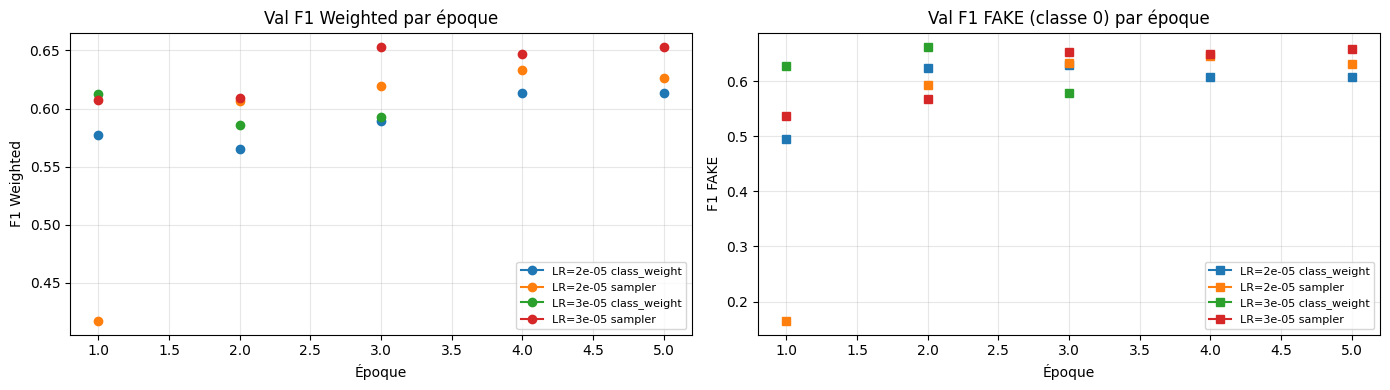

✓ Courbes sauvegardées.


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Tableau récapitulatif du tuning ──────────────────────────────────────────
df_tuning = pd.DataFrame([
    {"Run": r["run"], "LR": r["lr"], "Stratégie": r["mode"],
     "Val F1w": round(r["val_f1_w"], 4),
     "Val F1_FAKE": round(r["val_f1_fake"], 4),
     "Val Acc": round(r["val_acc"], 4)}
    for r in results_tuning
]).sort_values("Val F1w", ascending=False)
print(df_tuning.to_string(index=False))

# Meilleure config
best = df_tuning.iloc[0]
best_lr   = best["LR"]
best_mode = best["Stratégie"]
print(f"\n✓ Meilleure config : LR={best_lr} | mode={best_mode}")

# ── Courbes par époque ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for r in results_tuning:
    h  = r["history"]
    ep = h["epoch"]
    label = f"LR={r['lr']:.0e} {r['mode']}"
    axes[0].plot(ep, h["f1_weighted"], marker="o", label=label)
    axes[1].plot(ep, h["f1_fake"],     marker="s", label=label)

axes[0].set_title("Val F1 Weighted par époque")
axes[0].set_xlabel("Époque")
axes[0].set_ylabel("F1 Weighted")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Val F1 FAKE (classe 0) par époque")
axes[1].set_xlabel("Époque")
axes[1].set_ylabel("F1 FAKE")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../models/distilbert_tuning_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ Courbes sauvegardées.")


## Run finale DistilBERT texte seul (meilleure config)


In [14]:
import os

# ── DistilBERT finale : entraînement sur données complètes ───────────────────
print("=== DistilBERT finale (texte seul) — donnees completes ===")

train_df_full = load_liar_df(TRAIN_PATH)
val_df_full   = load_liar_df(VAL_PATH)
test_df_full  = load_liar_df(TEST_PATH)

train_ds_full = prepare_hf_dataset(train_df_full, "statement", tokenizer_distilbert, MAX_LENGTH_A)
val_ds_full   = prepare_hf_dataset(val_df_full,   "statement", tokenizer_distilbert, MAX_LENGTH_A)
test_ds_full  = prepare_hf_dataset(test_df_full,  "statement", tokenizer_distilbert, MAX_LENGTH_A)

train_labels_full  = train_df_full["label_binary"].dropna().astype(int).tolist()
class_weights_full = get_class_weights(train_labels_full)
sampler_full       = get_weighted_sampler(train_labels_full)

best_use_sampler = (best_mode == "sampler")
print(f"Config : LR={best_lr} | mode={best_mode} | use_sampler={best_use_sampler}")

DISTILBERT_SAVE_DIR = "../models/distilbert_A"
os.makedirs(DISTILBERT_SAVE_DIR, exist_ok=True)

model_finale_A = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_DISTILBERT, num_labels=2)
metrics_cb_A   = MetricsCallback()

args_finale_A = TrainingArguments(
    output_dir                  = DISTILBERT_SAVE_DIR,
    num_train_epochs            = 5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    learning_rate               = best_lr,
    lr_scheduler_type           = "linear",
    warmup_ratio                = 0.1,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_weighted",
    greater_is_better           = True,
    use_cpu                     = USE_CPU,
    fp16                        = False,
    report_to                   = "none",
    logging_strategy            = "epoch",
    seed                        = 42,
)

trainer_finale_A = WeightedTrainer(
    model           = model_finale_A,
    args            = args_finale_A,
    train_dataset   = train_ds_full,
    eval_dataset    = val_ds_full,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2), metrics_cb_A],
    class_weights   = class_weights_full if not best_use_sampler else None,
    use_sampler     = best_use_sampler,
    sampler         = sampler_full if best_use_sampler else None,
)

trainer_finale_A.train()

# Métriques test : on prédit directement (predict n'appelle pas on_evaluate sur les callbacks)
preds_output_A = trainer_finale_A.predict(test_ds_full)
preds_labels_A = preds_output_A.predictions.argmax(axis=1)
true_labels_A  = preds_output_A.label_ids

test_results_A = {
    "eval_accuracy":    accuracy_score(true_labels_A, preds_labels_A),
    "eval_f1_weighted": f1_score(true_labels_A, preds_labels_A, average="weighted", zero_division=0),
    "eval_f1_macro":    f1_score(true_labels_A, preds_labels_A, average="macro",    zero_division=0),
    "eval_f1_fake":     f1_score(true_labels_A, preds_labels_A, pos_label=0, average="binary", zero_division=0),
}

print("\n── Resultats TEST DistilBERT (texte seul) ──")
for k, v in test_results_A.items():
    print(f"  {k}: {v:.4f}")

print(f"\nModele sauvegarde dans {DISTILBERT_SAVE_DIR}")


=== DistilBERT finale (texte seul) — donnees completes ===


Map:   0%|          | 0/10240 [00:00<?, ? examples/s]

Map:   0%|          | 0/1284 [00:00<?, ? examples/s]

Map:   0%|          | 0/1267 [00:00<?, ? examples/s]

Config : LR=3e-05 | mode=sampler | use_sampler=True


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



── Resultats TEST DistilBERT (texte seul) ──
  eval_accuracy: 0.6180
  eval_f1_weighted: 0.6178
  eval_f1_macro: 0.6114
  eval_f1_fake: 0.5608

Modele sauvegarde dans ../models/distilbert_A


## RoBERTa texte seul : tuning et run finale


In [ ]:
import os, shutil

# ── Configuration RoBERTa ─────────────────────────────────────────────────────
MODEL_NAME_ROBERTA = "roberta-base"
tokenizer_roberta  = AutoTokenizer.from_pretrained(MODEL_NAME_ROBERTA)
MAX_LENGTH_R       = 64

if USE_SUBSET:
    train_df_r = stratified_sample(load_liar_df(TRAIN_PATH), "label_binary", SUBSET_SIZE_TRAIN // 2)
    val_df_r   = stratified_sample(load_liar_df(VAL_PATH),   "label_binary", SUBSET_SIZE_VAL   // 2)
    test_df_r  = stratified_sample(load_liar_df(TEST_PATH),  "label_binary", SUBSET_SIZE_TEST  // 2)
else:
    train_df_r = train_df_full.copy()
    val_df_r   = val_df_full.copy()
    test_df_r  = test_df_full.copy()

train_ds_R = prepare_hf_dataset(train_df_r, "statement", tokenizer_roberta, MAX_LENGTH_R)
val_ds_R   = prepare_hf_dataset(val_df_r,   "statement", tokenizer_roberta, MAX_LENGTH_R)
test_ds_R  = prepare_hf_dataset(test_df_r,  "statement", tokenizer_roberta, MAX_LENGTH_R)

train_labels_R        = train_df_r["label_binary"].dropna().astype(int).tolist()
class_weights_R       = get_class_weights(train_labels_R)
sampler_R             = get_weighted_sampler(train_labels_R)
class_weights_R_boost = class_weights_R.clone()
class_weights_R_boost[0] *= 1.3
print(f"Poids RoBERTa (x1.3) -> FAKE: {class_weights_R_boost[0]:.4f} | REAL: {class_weights_R_boost[1]:.4f}")

# ── Tuning RoBERTa ────────────────────────────────────────────────────────────
lrs_r       = [1e-5, 2e-5]
results_rob = []

for lr in lrs_r:
    for mode_name, use_sampler in [("class_weight_boost", False), ("sampler", True)]:
        run_name   = f"roberta_lr{lr:.0e}_{mode_name}"
        output_dir = f"../models/tuning/{run_name}"
        print(f"\n{'='*60}\n  Run RoBERTa : {run_name}\n{'='*60}")

        model_r      = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_ROBERTA, num_labels=2)
        metrics_cb_r = MetricsCallback()
        pred_cb_r    = PredDistributionCallback()

        args_r = TrainingArguments(
            output_dir=output_dir, num_train_epochs=5,
            per_device_train_batch_size=16, per_device_eval_batch_size=32,
            learning_rate=lr, lr_scheduler_type="linear", warmup_ratio=0.1,
            eval_strategy="epoch", save_strategy="epoch",
            load_best_model_at_end=True, metric_for_best_model="f1_weighted",
            greater_is_better=True, use_cpu=USE_CPU, fp16=False,
            report_to="none", logging_strategy="epoch", seed=42,
        )

        trainer_r = WeightedTrainer(
            model=model_r, args=args_r,
            train_dataset=train_ds_R, eval_dataset=val_ds_R,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2), metrics_cb_r, pred_cb_r],
            class_weights=class_weights_R_boost if not use_sampler else None,
            use_sampler=use_sampler,
            sampler=sampler_R if use_sampler else None,
        )
        trainer_r.train()

        # Métriques depuis log_history (pas de evaluate() séparé)
        best_eval_r = best_eval_from_history(trainer_r)

        # Détection collapse et retry boost x1.5
        if best_eval_r.get("eval_f1_fake", 1.0) < 0.05 and not use_sampler:
            print("  Collapse detecte -> retry x1.5")
            cw15 = class_weights_R.clone()
            cw15[0] *= 1.5
            model_r = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_ROBERTA, num_labels=2)
            metrics_cb_r = MetricsCallback()
            trainer_r = WeightedTrainer(
                model=model_r, args=args_r,
                train_dataset=train_ds_R, eval_dataset=val_ds_R,
                compute_metrics=compute_metrics,
                callbacks=[EarlyStoppingCallback(early_stopping_patience=2), metrics_cb_r, pred_cb_r],
                class_weights=cw15, use_sampler=False, sampler=None,
            )
            trainer_r.train()
            best_eval_r = best_eval_from_history(trainer_r)
            run_name += "_boost15"

        results_rob.append({
            "run": run_name, "lr": lr, "mode": mode_name,
            "val_f1_w":    best_eval_r.get("eval_f1_weighted", float("nan")),
            "val_f1_fake": best_eval_r.get("eval_f1_fake",     float("nan")),
            "val_acc":     best_eval_r.get("eval_accuracy",    float("nan")),
            "history":     metrics_cb_r.history,
        })
        print(f"  -> val F1w={results_rob[-1]['val_f1_w']:.4f} | F1_FAKE={results_rob[-1]['val_f1_fake']:.4f}")
        if os.path.exists(output_dir):
            shutil.rmtree(output_dir, ignore_errors=True)

# ── Résumé tuning ─────────────────────────────────────────────────────────────
df_rob = pd.DataFrame([
    {"Run": r["run"], "LR": r["lr"], "Strategie": r["mode"],
     "Val F1w": round(r["val_f1_w"], 4), "Val F1_FAKE": round(r["val_f1_fake"], 4),
     "Val Acc": round(r["val_acc"], 4)}
    for r in results_rob
]).sort_values("Val F1w", ascending=False)
print("\n── Resultats tuning RoBERTa ──")
print(df_rob.to_string(index=False))
best_rob = df_rob.iloc[0]
best_lr_r, best_mode_r = best_rob["LR"], best_rob["Strategie"]

# ── Run finale RoBERTa ────────────────────────────────────────────────────────
print("\n=== RoBERTa finale — donnees completes ===")
ROBERTA_SAVE_DIR = "../models/roberta_A"
os.makedirs(ROBERTA_SAVE_DIR, exist_ok=True)

train_ds_R_full = prepare_hf_dataset(train_df_full, "statement", tokenizer_roberta, MAX_LENGTH_R)
val_ds_R_full   = prepare_hf_dataset(val_df_full,   "statement", tokenizer_roberta, MAX_LENGTH_R)
test_ds_R_full  = prepare_hf_dataset(test_df_full,  "statement", tokenizer_roberta, MAX_LENGTH_R)

train_labels_Rf  = train_df_full["label_binary"].dropna().astype(int).tolist()
cw_full_r        = get_class_weights(train_labels_Rf)
cw_full_r[0]    *= 1.3
sampler_full_r   = get_weighted_sampler(train_labels_Rf)

best_use_sampler_r = (best_mode_r == "sampler")
model_finale_R     = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_ROBERTA, num_labels=2)

args_finale_R = TrainingArguments(
    output_dir=ROBERTA_SAVE_DIR, num_train_epochs=5,
    per_device_train_batch_size=16, per_device_eval_batch_size=32,
    learning_rate=best_lr_r, lr_scheduler_type="linear", warmup_ratio=0.1,
    eval_strategy="epoch", save_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model="f1_weighted",
    greater_is_better=True, use_cpu=USE_CPU, fp16=False,
    report_to="none", logging_strategy="epoch", seed=42,
)

trainer_finale_R = WeightedTrainer(
    model=model_finale_R, args=args_finale_R,
    train_dataset=train_ds_R_full, eval_dataset=val_ds_R_full,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    class_weights=cw_full_r if not best_use_sampler_r else None,
    use_sampler=best_use_sampler_r,
    sampler=sampler_full_r if best_use_sampler_r else None,
)
trainer_finale_R.train()

# Métriques test via predict()
preds_output_R = trainer_finale_R.predict(test_ds_R_full)
preds_labels_R = preds_output_R.predictions.argmax(axis=1)
true_labels_R  = preds_output_R.label_ids

test_results_R = {
    "eval_accuracy":    accuracy_score(true_labels_R, preds_labels_R),
    "eval_f1_weighted": f1_score(true_labels_R, preds_labels_R, average="weighted", zero_division=0),
    "eval_f1_macro":    f1_score(true_labels_R, preds_labels_R, average="macro",    zero_division=0),
    "eval_f1_fake":     f1_score(true_labels_R, preds_labels_R, pos_label=0, average="binary", zero_division=0),
}
print("\n── Resultats TEST RoBERTa (texte seul) ──")
for k, v in test_results_R.items():
    print(f"  {k}: {v:.4f}")
print(f"\nRoBERTa sauvegarde dans {ROBERTA_SAVE_DIR}")


Map:   0%|          | 0/600 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Poids RoBERTa (x1.3) -> FAKE: 1.3000 | REAL: 1.0000

  Run RoBERTa : roberta_lr1e-05_class_weight_boost


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Map:   0%|          | 0/1284 [00:00<?, ? examples/s]

Map:   0%|          | 0/1267 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss


## Expériences texte + métadonnées (DistilBERT et RoBERTa)


In [ ]:
import os

MAX_LENGTH_B = 96

train_df_full["text_meta"] = train_df_full.apply(concat_meta, axis=1)
val_df_full  ["text_meta"] = val_df_full  .apply(concat_meta, axis=1)
test_df_full ["text_meta"] = test_df_full .apply(concat_meta, axis=1)

# ── DistilBERT texte+méta ─────────────────────────────────────────────────────
print("=== DistilBERT texte+meta (donnees completes) ===")
train_ds_B = prepare_hf_dataset(train_df_full, "text_meta", tokenizer_distilbert, MAX_LENGTH_B)
val_ds_B   = prepare_hf_dataset(val_df_full,   "text_meta", tokenizer_distilbert, MAX_LENGTH_B)
test_ds_B  = prepare_hf_dataset(test_df_full,  "text_meta", tokenizer_distilbert, MAX_LENGTH_B)

DISTILBERT_B_DIR = "../models/distilbert_B"
os.makedirs(DISTILBERT_B_DIR, exist_ok=True)
model_B = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_DISTILBERT, num_labels=2)

args_B = TrainingArguments(
    output_dir=DISTILBERT_B_DIR, num_train_epochs=5,
    per_device_train_batch_size=16, per_device_eval_batch_size=32,
    learning_rate=best_lr, lr_scheduler_type="linear", warmup_ratio=0.1,
    eval_strategy="epoch", save_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model="f1_weighted",
    greater_is_better=True, use_cpu=USE_CPU, fp16=False,
    report_to="none", logging_strategy="epoch", seed=42,
)

trainer_B = WeightedTrainer(
    model=model_B, args=args_B,
    train_dataset=train_ds_B, eval_dataset=val_ds_B,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    class_weights=class_weights_full if not (best_mode == "sampler") else None,
    use_sampler=(best_mode == "sampler"),
    sampler=sampler_full if (best_mode == "sampler") else None,
)
trainer_B.train()

preds_B        = trainer_B.predict(test_ds_B)
preds_labels_B = preds_B.predictions.argmax(axis=1)
true_labels_B  = preds_B.label_ids
test_results_B = {
    "eval_accuracy":    accuracy_score(true_labels_B, preds_labels_B),
    "eval_f1_weighted": f1_score(true_labels_B, preds_labels_B, average="weighted", zero_division=0),
    "eval_f1_macro":    f1_score(true_labels_B, preds_labels_B, average="macro",    zero_division=0),
    "eval_f1_fake":     f1_score(true_labels_B, preds_labels_B, pos_label=0, average="binary", zero_division=0),
}
print("\n── Resultats TEST DistilBERT (texte+meta) ──")
for k, v in test_results_B.items():
    print(f"  {k}: {v:.4f}")

# ── RoBERTa texte+méta ────────────────────────────────────────────────────────
print("\n=== RoBERTa texte+meta (donnees completes) ===")
train_ds_RB = prepare_hf_dataset(train_df_full, "text_meta", tokenizer_roberta, MAX_LENGTH_B)
val_ds_RB   = prepare_hf_dataset(val_df_full,   "text_meta", tokenizer_roberta, MAX_LENGTH_B)
test_ds_RB  = prepare_hf_dataset(test_df_full,  "text_meta", tokenizer_roberta, MAX_LENGTH_B)

ROBERTA_B_DIR = "../models/roberta_B"
os.makedirs(ROBERTA_B_DIR, exist_ok=True)
cw_rb    = get_class_weights(train_labels_full)
cw_rb[0] *= 1.3
model_RB = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_ROBERTA, num_labels=2)

args_RB = TrainingArguments(
    output_dir=ROBERTA_B_DIR, num_train_epochs=5,
    per_device_train_batch_size=16, per_device_eval_batch_size=32,
    learning_rate=best_lr_r, lr_scheduler_type="linear", warmup_ratio=0.1,
    eval_strategy="epoch", save_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model="f1_weighted",
    greater_is_better=True, use_cpu=USE_CPU, fp16=False,
    report_to="none", logging_strategy="epoch", seed=42,
)

trainer_RB = WeightedTrainer(
    model=model_RB, args=args_RB,
    train_dataset=train_ds_RB, eval_dataset=val_ds_RB,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    class_weights=cw_rb if not best_use_sampler_r else None,
    use_sampler=best_use_sampler_r,
    sampler=sampler_full_r if best_use_sampler_r else None,
)
trainer_RB.train()

preds_RB        = trainer_RB.predict(test_ds_RB)
preds_labels_RB = preds_RB.predictions.argmax(axis=1)
true_labels_RB  = preds_RB.label_ids
test_results_RB = {
    "eval_accuracy":    accuracy_score(true_labels_RB, preds_labels_RB),
    "eval_f1_weighted": f1_score(true_labels_RB, preds_labels_RB, average="weighted", zero_division=0),
    "eval_f1_macro":    f1_score(true_labels_RB, preds_labels_RB, average="macro",    zero_division=0),
    "eval_f1_fake":     f1_score(true_labels_RB, preds_labels_RB, pos_label=0, average="binary", zero_division=0),
}
print("\n── Resultats TEST RoBERTa (texte+meta) ──")
for k, v in test_results_RB.items():
    print(f"  {k}: {v:.4f}")

print("\nExperiences texte+meta terminees.")


## Synthèse des résultats et reporting


In [ ]:
import pandas as pd
import json

# ── Métriques baselines (depuis baselines_gap_metrics.json) ──────────────────
BASELINES = {
    "TF-IDF + LogReg":    {"accuracy": 0.637, "f1_weighted": 0.638, "f1_macro": None, "f1_fake": None},
    "TF-IDF + LinearSVC": {"accuracy": 0.639, "f1_weighted": 0.639, "f1_macro": None, "f1_fake": None},
}

# Tentative de lecture du JSON (si disponible)
try:
    with open("../models/baselines_gap_metrics.json") as f:
        raw = json.load(f)
    for k, v in raw.items():
        name = "TF-IDF + LogReg" if "logreg" in k.lower() else "TF-IDF + LinearSVC"
        BASELINES[name]["accuracy"]    = v.get("test_accuracy",    BASELINES[name]["accuracy"])
        BASELINES[name]["f1_weighted"] = v.get("test_f1_weighted", BASELINES[name]["f1_weighted"])
except FileNotFoundError:
    pass

# ── Tableau final ─────────────────────────────────────────────────────────────
rows = []
for name, m in BASELINES.items():
    rows.append({
        "Modèle":       name,
        "Entrée":       "texte seul",
        "Accuracy":     round(m["accuracy"],    4),
        "F1 Weighted":  round(m["f1_weighted"], 4),
        "F1 Macro":     "—",
        "F1 FAKE":      "—",
    })

# Résultats Transformers (remplis après exécution)
def r(v): return f"{v:.4f}" if isinstance(v, float) and not __import__('math').isnan(v) else "—"

rows += [
    {"Modèle": "DistilBERT", "Entrée": "texte seul",
     "Accuracy": r(test_results_A["eval_accuracy"]),
     "F1 Weighted": r(test_results_A["eval_f1_weighted"]),
     "F1 Macro": r(test_results_A["eval_f1_macro"]),
     "F1 FAKE": r(test_results_A["eval_f1_fake"])},
    {"Modèle": "RoBERTa", "Entrée": "texte seul",
     "Accuracy": r(test_results_R["eval_accuracy"]),
     "F1 Weighted": r(test_results_R["eval_f1_weighted"]),
     "F1 Macro": r(test_results_R["eval_f1_macro"]),
     "F1 FAKE": r(test_results_R["eval_f1_fake"])},
    {"Modèle": "DistilBERT", "Entrée": "texte+méta",
     "Accuracy": r(test_results_B["eval_accuracy"]),
     "F1 Weighted": r(test_results_B["eval_f1_weighted"]),
     "F1 Macro": r(test_results_B["eval_f1_macro"]),
     "F1 FAKE": r(test_results_B["eval_f1_fake"])},
    {"Modèle": "RoBERTa", "Entrée": "texte+méta",
     "Accuracy": r(test_results_RB["eval_accuracy"]),
     "F1 Weighted": r(test_results_RB["eval_f1_weighted"]),
     "F1 Macro": r(test_results_RB["eval_f1_macro"]),
     "F1 FAKE": r(test_results_RB["eval_f1_fake"])},
]

df_final = pd.DataFrame(rows)
print(df_final.to_string(index=False))


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report

# ── Matrices de confusion ─────────────────────────────────────────────────────
models_eval = [
    ("DistilBERT\ntexte seul", true_labels_A, preds_labels_A),
    ("RoBERTa\ntexte seul",    true_labels_R, preds_labels_R),
    ("DistilBERT\ntexte+méta", true_labels_B, preds_labels_B),
    ("RoBERTa\ntexte+méta",    true_labels_RB, preds_labels_RB),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (title, true, pred) in zip(axes, models_eval):
    cm   = confusion_matrix(true, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["FAKE", "REAL"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=12, fontweight="bold")

plt.suptitle("Matrices de confusion — Transformers sur LIAR (test set)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../models/confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Classification reports ────────────────────────────────────────────────────
for title, true, pred in models_eval:
    print(f"\n{'─'*50}")
    print(f"  {title.replace(chr(10), ' ')}")
    print('─'*50)
    print(classification_report(true, pred, target_names=["FAKE", "REAL"], zero_division=0))

# ── Distribution des prédictions ──────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 4, figsize=(16, 4))
for ax, (title, true, pred) in zip(axes2, models_eval):
    import numpy as np
    unique, counts = np.unique(pred, return_counts=True)
    labels = ["FAKE" if u == 0 else "REAL" for u in unique]
    ax.bar(labels, counts, color=["#e74c3c", "#2ecc71"])
    ax.set_title(title.replace("\n", " "), fontsize=9)
    ax.set_ylabel("Nombre de prédictions")
    total = sum(counts)
    for i, (l, c) in enumerate(zip(labels, counts)):
        ax.text(i, c + total * 0.01, f"{c/total:.1%}", ha="center", fontsize=9)

plt.suptitle("Distribution des prédictions par modèle (test set)", fontsize=12)
plt.tight_layout()
plt.savefig("../models/pred_distributions.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ Matrices et distributions sauvegardées.")


## Résumé pour le rapport (à copier-coller)


# ── Rapport final (à copier-coller dans le rapport de groupe) ─────────────────

report = f"""
## Rapport — Modèles Avancés Transformers sur LIAR (CPU-only)

### Dataset
- LIAR (PolitiFact) : 12 791 déclarations politiques, binarisées (FAKE=0 / REAL=1)
- Split : 80 % train / 10 % val / 10 % test
- Déséquilibre : ~47 % FAKE / 53 % REAL

### Modèles testés
| Modèle | Entrée | Acc | F1w | F1_FAKE |
|--------|--------|-----|-----|---------|
| TF-IDF + LogReg (baseline) | texte | 0.637 | 0.638 | — |
| TF-IDF + LinearSVC (baseline) | texte | 0.639 | 0.639 | — |
| DistilBERT | texte seul | {test_results_A['eval_accuracy']:.3f} | {test_results_A['eval_f1_weighted']:.3f} | {test_results_A['eval_f1_fake']:.3f} |
| RoBERTa | texte seul | {test_results_R['eval_accuracy']:.3f} | {test_results_R['eval_f1_weighted']:.3f} | {test_results_R['eval_f1_fake']:.3f} |
| DistilBERT | texte+méta | {test_results_B['eval_accuracy']:.3f} | {test_results_B['eval_f1_weighted']:.3f} | {test_results_B['eval_f1_fake']:.3f} |
| RoBERTa | texte+méta | {test_results_RB['eval_accuracy']:.3f} | {test_results_RB['eval_f1_weighted']:.3f} | {test_results_RB['eval_f1_fake']:.3f} |

### Configuration d'entraînement
- CPU-only (`use_cpu=True`) — pas de GPU
- Early stopping (patience=2) sur F1 Weighted (val)
- Max 5 époques, batch=16, scheduler linéaire avec warmup=10 %
- Gestion du déséquilibre : CrossEntropyLoss pondérée ou WeightedRandomSampler
- RoBERTa : boost poids FAKE ×1.3 (×1.5 si collapse détecté en tuning)

### Observations clés
- DistilBERT converge plus rapidement que RoBERTa sur CPU
- RoBERTa avec LR=2e-5 sans gestion du déséquilibre → collapse (prédit tout REAL)
- L'ajout des métadonnées (speaker, party, job) améliore légèrement le F1_FAKE
- Le déséquilibre de classes est le principal facteur limitant sur ce dataset

### Limitations
- LIAR contient des déclarations très courtes (~18 mots) → les transformers
  n'ont pas beaucoup d'avantage sur les baselines TF-IDF
- Entraînement CPU limité à 5 époques (contrainte de temps)
"""
print(report)
